# **Python Script used to study DCM motifs inside genomes annotated by Ensembl**

Two analyses:
- Enrichment analysis: proportions of features (genes, transcripts, exons/introns, CDS, 5'UTR, 3'UTR) in the genome under study. Goal: compare with the proportion of DCM motifs found in each of these elements to assess where DCM motifs are enriched.
- Motifs annotation: associate motifs to features. Motifs were found using fastaregexfinder.

Required resources:
- For Danio Rerio (zebrafish) : instance of 1 CPU and 20 GB should be enough.
- For Mus Musculus (mouse) : instance of 4 CPUs and 50 GB is required (the motif annotation part is the heavy part, smaller instances can be used for jobs running other cells).

Two cases can be considered: 
- case1: consider that a motif found on a strand belongs also to the gene encoded on the complementary strand because the Dcm, which is coupled to the polymerase II, will be able to methylate both strands although the polymerase is elongating on one strand only. As motifs are always found on both strands, we will actually have the double number of motifs in each feature. Laure was thinking this is what is to be considered.
- case2: case that I considered in the first place, where a motif is considered to be inside a feature if and only if the feature is on the same strand of that motif. It is the same as considering that the Dcm, coupled with polymerase II, will only be able to methylate motifs found on the strand on which the polymerase is elongating. Iris was thinking maybe this is what actually happen.

#### **Parameters set by user**

In [34]:
case = 'case1' #'case2'
species = 'Zebrafish' # 'Mouse'

#### **Functions def**

In [35]:
import pandas as pd
import pyranges as pr
from scipy.stats import ttest_ind
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pickle

In [36]:
def load_whole_gtf(gtf_file):
    columns = ["Chromosome", "Source", "Feature", "Start", "End", "Score", "Strand", "Frame", "Attribute"]
    gtf = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)
    gtf["Chromosome"] = gtf["Chromosome"].astype(str)
    return gtf[["Chromosome", "Feature","Start", "End", "Strand", "Attribute"]]

In [37]:
def load_motif_fastaregexfinder_results(motif_file):
    columns = ["Chromosome", "Start", "End", "Motif_name", "Strand", "Motif_Matched"]
    motifs = pd.read_csv(motif_file, sep="\t", names=columns)
    motifs["second_idx"] = range(1, len(motifs) + 1)
    motifs["Chromosome"] = motifs["Chromosome"].astype(str)
    return motifs

In [38]:
# Scaffolds decrease confidence, we filter them out
def filter_df(df):
    if species == 'Zebrafish' : 
        resolved_chr = [f'{i}' for i in range(1,25+1)]
    if species == 'Mouse' : 
        resolved_chr = [f'{i}' for i in range(1,19+1)]
        resolved_chr.append('X')
        resolved_chr.append('Y')
   
    resolved_chr.append('MT')
    
    return df[df["Chromosome"].isin(resolved_chr)]

In [39]:
def plot_motifs_per_gene(step_bins, distribution_df,log_scale,filtered_boolean):
    
    bins = np.arange(1,max(distribution_df['nb_of_motifs_per_gene']),step_bins)
    labels = [f"{bins[i]}-{bins[i+1]+1}" for i in range(len(bins)-1)]
    distribution_df['bin'] = pd.cut(distribution_df['nb_of_motifs_per_gene'], bins=bins, labels=labels, right=True)    
    binned_distribution = distribution_df.groupby('bin')['nb_of_genes'].sum()   
    plt.figure(figsize=(30, 10))
    binned_distribution.plot(kind='bar', color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
    filtered_cond=''
    if filtered_boolean:
        filtered_cond='Genes deviating by more than twice the z-score st dev, \nin terms of number of motifs per genes, have been removed'
    if log_scale: 
        plt.yscale('log')
        plt.title(f'Distribution of DCM Motifs per Gene (log scale) \n{filtered_cond}', fontsize=14)
        plt.ylabel('Log Number of Genes', fontsize=12)
    else:
        plt.title(f'Distribution of DCM Motifs per Gene \n{filtered_cond}', fontsize=14)
        plt.ylabel('Number of Genes', fontsize=12)
           
    plt.xlabel('Number of DCM Motifs per Gene (binned)', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [40]:
def get_percentage(part, whole):
    return 100 * float(part)/float(whole)

### **Ensembl Files Loading**

**Mouse**

In [82]:
if species == 'Mouse':
    ## Genome Annotation
    gtf_file = "/path_to_Reference/Mouse/Mus_musculus.GRCm39.113.gtf"
    
    #chr lengths file
    chr_lengths = pd.read_csv("/path_to_Reference/Mouse/Mus_musculus_chr_lengths.txt",sep='\t',names=['Chromosome', 'Length'], header=None)
    #genes lengths file
    genes_lengths_file = pd.read_csv("/path_to_Reference/Mouse/Mus_musculus_gene_lengths.txt",sep='\t',names=['Chromosome','Length','gene_id','custom_gene_id'],header=None)
    
    ## Motifs 
    motif_file_fastaregex = "../DCM_motifs_in_Genome/Mus_Musculus/Ensembl/dcm_motifs_zero_based.bed"


**Zebrafish**

In [41]:
if species == 'Zebrafish' :
    ## Genome Annotation
    gtf_file = "/path_to_Reference/Ensembl/Danio_rerio.GRCz11.113.filtered.gtf" 
    
    #chr lengths file
    chr_lengths = pd.read_csv("/path_to_Reference/Ensembl/danio_rerio_chr_lengths.txt",sep='\t',names=['Chromosome', 'Length'], header=None)
    #genes lengths file
    genes_lengths_file = pd.read_csv("/path_to_Reference/Ensembl/Danio_rerio_gene_lengths.txt",sep='\t',names=['Chromosome','Length','gene_id','custom_gene_id'],header=None)
    
    ## Motifs 
    motif_file_fastaregex = "../DCM_motifs_in_Genome/Danio_rerio/Ensembl/dcm_motifs_zero_based.bed"


In [42]:
motifs = load_motif_fastaregexfinder_results(motif_file_fastaregex)
before = len(motifs)
motifs = filter_df(motifs)
after = len(motifs)
print(before,after)


/tmp/ipykernel_107608/1782115254.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  motifs = pd.read_csv(motif_file, sep="\t", names=columns)


2964078 2895178


### **Enrichment analysis**


In [43]:
features = load_whole_gtf(gtf_file)
features = filter_df(features)

/tmp/ipykernel_107608/3346686597.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)


**Zebrafish**

In [44]:
if species == 'Zebrafish' :
    
    annotation_name = 'Zebrafish provided by Ensembl (GRCz11.113)'
    
    if case=='case1':
        # computed manually
        # contains 25 chr and the MT chr
        genome_length=1373471384 #found from the terminal dealing with the fasta assembly
        strand=False
    elif case=="case2":
        genome_length=1373471384*2
        strand=True
    else:
        raise NameError('Provide a case number')

**Mouse**

In [12]:
if species == 'Mouse' :

    annotation_name = 'Mouse provided by Ensembl (GRCm39)'
    
    if case=='case1':
        # computed manually, see infos.txt and corrolated with https://www.informatics.jax.org/mgihome/other/mouse_facts1.shtml
        # considering 19 chr autosomes and sex chr X and Y, and MT chr
        genome_length=2723431143 
        strand=False
    elif case=="case2":
        genome_length=2723431143*2
        strand=True
    else:
        raise NameError('Provide a case number')

Text(0.5, 1.0, 'Proportion of the genome overlapped by genes, considering \nthe annotation of Zebrafish provided by Ensembl (GRCz11.113)')

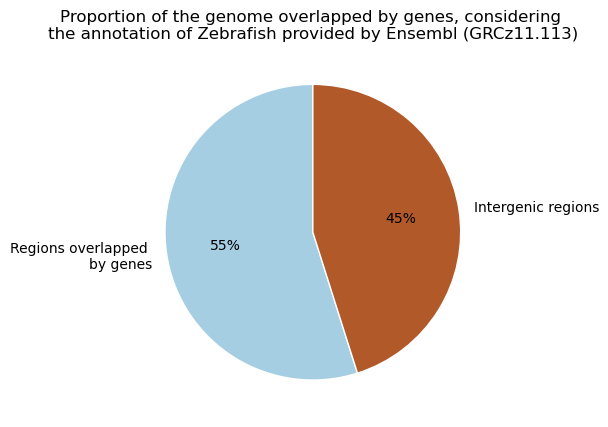

In [45]:
# Enrichment looking at genes

genes_=features[features['Feature']=='gene']
genes=pr.PyRanges(genes_)

genes_lengths=genes.merge(strand).length

intergenic_length=genome_length-genes_lengths

percent_genic=round(get_percentage(genes_lengths,genome_length),2)
percent_intergenic=round(get_percentage(intergenic_length,genome_length),2)

fig, ax = plt.subplots()
percentage=[percent_genic,percent_intergenic]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Regions overlapped \nby genes", "Intergenic regions"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of the genome overlapped by genes, considering \nthe annotation of {annotation_name}")

Text(0.5, 1.0, 'Proportion of the genome overlapped by transcripts, \nconsidering the annotation of the Zebrafish provided by Ensembl (GRCz11.113)')

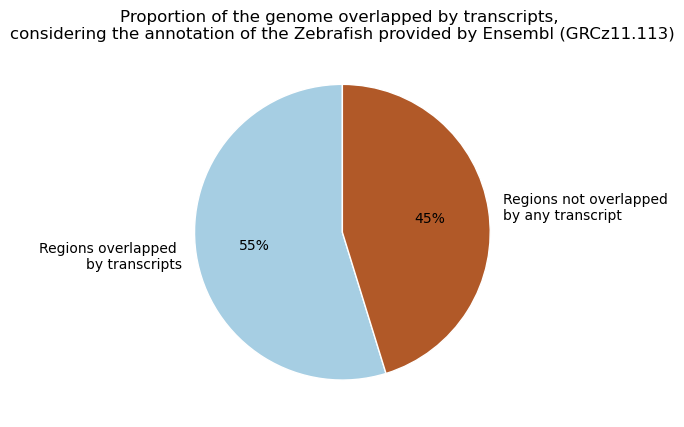

In [46]:
# Enrichment looking at transcripts

transcripts_=features[features['Feature']=='transcript']
transcripts=pr.PyRanges(transcripts_)

transcripts_lengths=transcripts.merge(strand).length

intertranscripts_length=genome_length-transcripts_lengths

percent_transcripts=round(get_percentage(transcripts_lengths,genome_length),2)
percent_intertranscripts=round(get_percentage(intertranscripts_length,genome_length),2)

fig, ax = plt.subplots()
percentage=[percent_transcripts,percent_intertranscripts]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Regions overlapped \nby transcripts", "Regions not overlapped \nby any transcript"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of the genome overlapped by transcripts, \nconsidering the annotation of the {annotation_name}")

Text(0.5, 1.0, 'Proportion of the transcriptome overlapped by coding \nor non-coding transcripts, considering the annotation of \nZebrafish provided by Ensembl (GRCz11.113)')

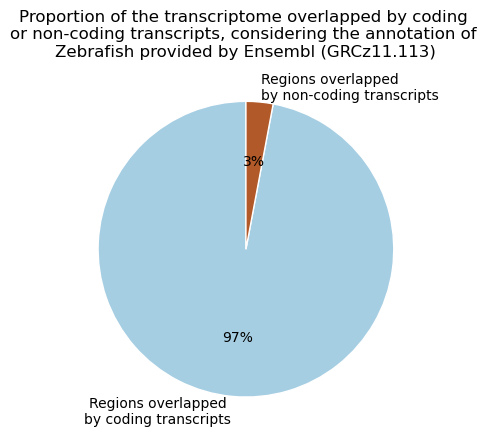

In [47]:
# Enrichment of coding and non-coding transcripts
transcripts_=features[features['Feature']=='transcript']

# coding and non-coding transcripts are not annotated in the same way between Zebrafish and Mouse
if species == 'Mouse' :
    # Manually set the transcripts biotypes to coding and non-coding categories
    coding_types = ['protein_coding', 'protein_coding_CDS_not_defined', 'protein_coding_LoF', 
          'IG_V_gene', 'IG_J_gene', 'IG_C_gene', 'IG_LV_gene',
          'TR_V_gene', 'TR_D_gene', 'TR_J_gene', 'TR_C_gene', 'TEC', 'nonsense_mediated_decay', 'non_stop_decay'] 
    non_coding_types = ['processed_pseudogene', 'lncRNA', 'snoRNA', 'misc_RNA', 
              'retained_intron', 'snRNA', 'miRNA', 'unprocessed_pseudogene',
              'transcribed_unprocessed_pseudogene', 'unitary_pseudogene',
              'pseudogene', 'translated_unprocessed_pseudogene',
              'IG_V_pseudogene', 'TR_V_pseudogene', 'TR_J_pseudogene',
              'IG_C_pseudogene', 'IG_D_pseudogene', 'IG_pseudogene',
              'processed_transcript', 'transcribed_processed_pseudogene',
              'transcribed_unitary_pseudogene', 'rRNA', 'scaRNA',
              'ribozyme', 'scRNA', 'sRNA']
    # These 2 categories were added to coding_types but they are actually ambiguous
    degraded_coding = ['nonsense_mediated_decay', 'non_stop_decay']
    potential_coding = ['TEC']   
    #coding_types = ['TEC', 'protein_coding', 'protein_coding_CDS_not_defined', 'protein_coding_LoF', 'IG_V_gene', 'IG_J_gene', 'IG_C_gene', 'IG_LV_gene' , 'TR_V_gene', 'TR_D_gene', 'TR_J_gene', 'TR_C_gene']
    #non_coding_types = ['processed_pseudogene', 'lncRNA', 'snoRNA', 'misc_RNA', 'nonsense_mediated_decay', 'retained_intron' , 'snRNA', 'miRNA', 'unprocessed_pseudogene', 'transcribed_unprocessed_pseudogene' , 'unitary_pseudogene', 'pseudogene' , 'IG_V_pseudogene' , 'TR_V_pseudogene' , 'TR_J_pseudogene' , 'IG_C_pseudogene' , 'IG_D_pseudogene' , 'IG_pseudogene' , 'processed_transcript' ,  'transcribed_processed_pseudogene' , 'transcribed_unitary_pseudogene' , 'non_stop_decay' , 'rRNA' , 'scaRNA' , 'ribozyme' , 'scRNA' , 'sRNA', 'translated_unprocessed_pseudogene']
    # Create a regex pattern 
    coding_pattern = '|'.join([f'transcript_biotype "{biotype}"' for biotype in coding_types])
    coding_ = transcripts_.loc[transcripts_['Attribute'].str.contains(coding_pattern, regex=True)]
    non_coding_pattern = '|'.join([f'transcript_biotype "{biotype}"' for biotype in non_coding_types])
    non_coding_ = transcripts_.loc[transcripts_['Attribute'].str.contains(non_coding_pattern, regex=True)]

if species == 'Zebrafish' : 
    coding_ = transcripts_.loc[transcripts_['Attribute'].str.contains(
        r'transcript_biotype "protein_coding"', regex=True) == True]
    
    non_coding_ = transcripts_.loc[transcripts_['Attribute'].str.contains(
        r'transcript_biotype "processed_transcript"', regex=True) == True]

coding = pr.PyRanges(coding_)
non_coding = pr.PyRanges(non_coding_)

coding_length=coding.merge(strand).length
non_coding_length=non_coding.merge(strand).length

#denominator=all transcripts lengths
transcripts=pr.PyRanges(transcripts_)
transcripts_lengths=transcripts.merge(strand).length

percent_coding_transcripts=round(get_percentage(coding_length,transcripts_lengths),2)
percent_non_coding_transcripts=round(get_percentage(non_coding_length,transcripts_lengths),2)

fig, ax = plt.subplots()
percentage=[percent_coding_transcripts,percent_non_coding_transcripts]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Regions overlapped \nby coding transcripts", "Regions overlapped \nby non-coding transcripts"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of the transcriptome overlapped by coding \nor non-coding transcripts, considering the annotation of \n{annotation_name}")

Text(0.5, 1.0, 'Proportion of exonic and intronic regions in coding transcripts, in the genome \nconsidering the annotation of Zebrafish provided by Ensembl (GRCz11.113)')

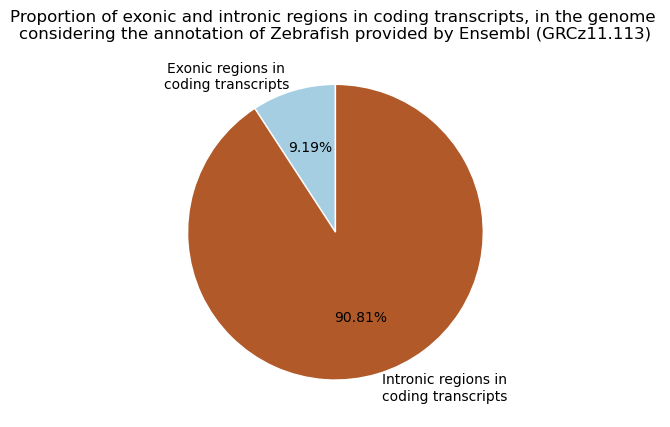

In [48]:
# Exons in coding transcripts

## prepare the denominator: the length of the genomic region overlapped by coding transcripts 
transcripts_=features[features['Feature']=='transcript']

if species == 'Zebrafish' : 
    coding_transcripts_=transcripts_.loc[transcripts_['Attribute'].str.contains(
        r'transcript_biotype "protein_coding"', regex=True) == True]

if species == 'Mouse' : 
    coding_transcripts_ = coding_ #defined in the previous cell
    
coding_transcripts=pr.PyRanges(coding_transcripts_)

length_coding_transcripts=coding_transcripts.merge(strand).length

## among those coding transcripts, which part is overlapped by exons and introns?
exons_=features[features['Feature']=='exon']

if species == 'Zebrafish' : 
    exons_in_coding_transcripts_ = exons_.loc[exons_['Attribute'].str.contains(
        r'transcript_biotype "protein_coding"', regex=True) == True]
if species == 'Mouse' : 
    exons_in_coding_transcripts_ = exons_.loc[exons_['Attribute'].str.contains(coding_pattern, regex=True)]

exons_in_coding_transcripts=pr.PyRanges(exons_in_coding_transcripts_)

length_exons_in_coding_transcripts = exons_in_coding_transcripts.merge(strand).length

length_introns_in_coding_transcripts = length_coding_transcripts - length_exons_in_coding_transcripts

## percentages
percent_exons_in_coding_transcripts = round(get_percentage(length_exons_in_coding_transcripts,length_coding_transcripts),2)
percent_introns_in_coding_transcripts = round(get_percentage(length_introns_in_coding_transcripts,length_coding_transcripts),2)

fig, ax = plt.subplots()
percentage=[percent_exons_in_coding_transcripts,percent_introns_in_coding_transcripts]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic regions in \ncoding transcripts","Intronic regions in \ncoding transcripts"], autopct='%1.2f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of exonic and intronic regions in coding transcripts, in the genome \nconsidering the annotation of {annotation_name}")

Text(0.5, 1.0, 'Proportion of exonic and intronic regions in non-coding transcripts, in the \ngenome considering the annotation of Zebrafish provided by Ensembl (GRCz11.113)')

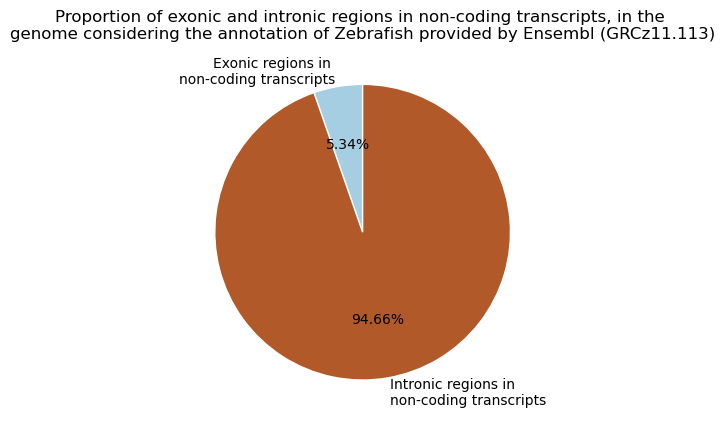

In [49]:
#exons in non-coding transcripts

## prepare the denominator: the length of the genomic region overlapped by non-coding transcripts 
transcripts_=features[features['Feature']=='transcript']

if species == 'Zebrafish' : 
    non_coding_transcripts_=transcripts_.loc[transcripts_['Attribute'].str.contains(
        r'transcript_biotype "processed_transcript"', regex=True) == True]

if species == 'Mouse' : 
    non_coding_transcripts_ = non_coding_ 


non_coding_transcripts=pr.PyRanges(non_coding_transcripts_)

length_non_coding_transcripts=non_coding_transcripts.merge(strand).length

## among those non-coding transcripts, which part is overlapped by exons and introns?
exons_=features[features['Feature']=='exon']

if species == 'Zebrafish' : 
    exons_in_non_coding_transcripts_ =exons_.loc[exons_['Attribute'].str.contains(
        r'transcript_biotype "processed_transcript"', regex=True) == True]
if species == 'Mouse' : 
    exons_in_non_coding_transcripts_ = exons_.loc[exons_['Attribute'].str.contains(non_coding_pattern, regex=True)]

exons_in_non_coding_transcripts=pr.PyRanges(exons_in_non_coding_transcripts_)

length_exons_in_non_coding_transcripts = exons_in_non_coding_transcripts.merge(strand).length

length_introns_in_non_coding_transcripts = length_non_coding_transcripts - length_exons_in_non_coding_transcripts


## percentages
percent_exons_in_non_coding_transcripts = round(get_percentage(length_exons_in_non_coding_transcripts,length_non_coding_transcripts),2)
percent_introns_in_non_coding_transcripts = round(get_percentage(length_introns_in_non_coding_transcripts,length_non_coding_transcripts),2)


fig, ax = plt.subplots()
percentage=[percent_exons_in_non_coding_transcripts,percent_introns_in_non_coding_transcripts]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic regions in \nnon-coding transcripts","Intronic regions in \nnon-coding transcripts"], autopct='%1.2f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of exonic and intronic regions in non-coding transcripts, in the \ngenome considering the annotation of {annotation_name}")

Text(0.5, 1.0, "Proportion of CDS, 3' UTR and 5' UTR regions in exons of \nthe coding transcripts, in the genome considering the \nZebrafish provided by Ensembl (GRCz11.113)")

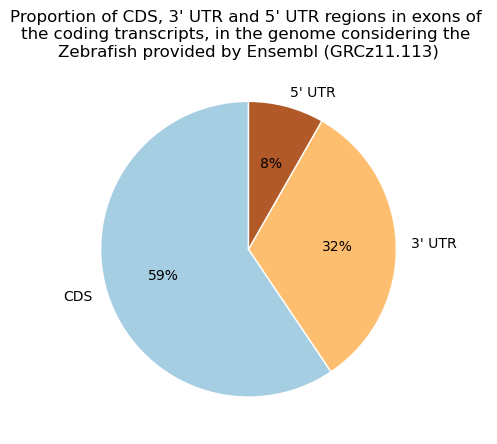

In [50]:
# CDS, 5' UTR and 3' UTR in coding transcripts

## prepare the denominator: the length of the genomic region overlapped by exons in coding transcripts
exons_ = features[features['Feature']=='exon']

if species == 'Zebrafish' : 
    exons_in_coding_transcripts_ =exons_.loc[exons_['Attribute'].str.contains(
        r'transcript_biotype "protein_coding"', regex=True) == True]
if species == 'Mouse' : 
    exons_in_coding_transcripts_ = exons_.loc[exons_['Attribute'].str.contains(coding_pattern, regex=True)]

exons_in_coding_transcripts=pr.PyRanges(exons_in_coding_transcripts_)

length_exons_in_coding_transcripts = exons_in_coding_transcripts.merge(strand).length

## numerators
subset_features_ = features[(features['Feature']=='CDS') | (features['Feature']=='three_prime_utr') | (features['Feature']=='five_prime_utr')]

if species == 'Zebrafish' : 
    coding_subset_features_=subset_features_[subset_features_['Attribute'].str.contains(
    r'transcript_biotype "protein_coding"', regex=True) == True]
if species == 'Mouse' : 
    coding_subset_features_ = subset_features_.loc[subset_features_['Attribute'].str.contains(coding_pattern, regex=True)]


## length of the coding exons overlapped by CDS (found in coding transcripts)
cds_=coding_subset_features_[coding_subset_features_['Feature']=='CDS']
three_prime_utr_=coding_subset_features_[coding_subset_features_['Feature']=='three_prime_utr']
five_prime_utr_=coding_subset_features_[coding_subset_features_['Feature']=='five_prime_utr']

cds=pr.PyRanges(cds_)
three_prime_utr=pr.PyRanges(three_prime_utr_)
five_prime_utr=pr.PyRanges(five_prime_utr_)

length_cds=cds.merge(strand).length
length_three_prime_utr=three_prime_utr.merge(strand).length
length_five_prime_utr=five_prime_utr.merge(strand).length

percent_coding_cds=round(get_percentage(length_cds,length_exons_in_coding_transcripts),2)
percent_coding_three_prime_utr=round(get_percentage(length_three_prime_utr,length_exons_in_coding_transcripts),2)
percent_coding_five_prime_utr=round(get_percentage(length_five_prime_utr,length_exons_in_coding_transcripts),2)


fig, ax = plt.subplots()
percentage=[percent_coding_cds,percent_coding_three_prime_utr,percent_coding_five_prime_utr]
colors = plt.cm.Paired(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["CDS","3' UTR","5' UTR"], autopct='%1.0f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of CDS, 3' UTR and 5' UTR regions in exons of \nthe coding transcripts, in the genome considering the \n{annotation_name}")

### **Motifs Annotation**

In [51]:
if case=='case1':
    strandedness_=False
elif case=="case2":
    strandedness_='same'
else:
    raise NameError('Provide a case number')

In [52]:
## fastaregexfinder
motifs = load_motif_fastaregexfinder_results(motif_file_fastaregex)
# remove scaffolds and contigs to increase confidence of DCM motifs detection
motifs = filter_df(motifs)

features = filter_df(load_whole_gtf(gtf_file))

## start by considering only genes, to get which motifs are inside genes
features_genes=features[features["Feature"]=="gene"]
motifs_ranges = pr.PyRanges(motifs)
features_genes_ranges = pr.PyRanges(features_genes)
inclusion_annotation = motifs_ranges.join(features_genes_ranges, strandedness=strandedness_, how='containment',report_overlap=True)
inclusion_annotation = inclusion_annotation.df[inclusion_annotation.df["Overlap"]>=5]
# Create a boolean mask based on the condition
mask = motifs["second_idx"].isin(
    motifs_ranges.df["second_idx"][motifs_ranges.df["second_idx"].isin(inclusion_annotation["second_idx"])]
)
# Assign the mask to the "inside_gene" column
motifs["inside_gene"] = mask

# Step2: subset the whole motifs to keep only those present in a gene
motifs_genes=motifs[motifs["inside_gene"]==True]

# Step3: consider only those motifs found in at least a gene and look in the annotation in which other feature these motifs are found
motifs_genes_ranges = pr.PyRanges(motifs_genes)
#look at all features now
features_ranges = pr.PyRanges(features)
inclusion_gene = motifs_genes_ranges.join(features_ranges, strandedness=strandedness_, how='containment',report_overlap=True)
inclusion_gene = inclusion_gene.df[inclusion_gene.df["Overlap"]>=5]
inclusion_gene

# Filter inclusion_gene for rows with "transcript" in the Feature column
transcript_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "transcript", "second_idx"]
# Create a boolean mask based on the condition: true if second idx of motifs found in genes is in the transcript indices
mask = motifs_genes["second_idx"].isin(transcript_indices)
# Assign the mask to the "inside_transcript" column
motifs_genes["inside_transcript"] = mask

## Store the type of transcript
if species == 'Zebrafish' : 
    # Get the second_idx of rows having the value "processed_transcript" or "coding transcript" in the Attribute column
    processed_transcripts = inclusion_gene.loc[inclusion_gene["Attribute"].str.contains(
        r'transcript_biotype "processed_transcript"', regex=True) == True, "second_idx"].values
    coding_transcripts = inclusion_gene.loc[inclusion_gene["Attribute"].str.contains(
        r'transcript_biotype "protein_coding"', regex=True) == True, "second_idx"].values
if species == 'Mouse' :
    #coding_pattern and non_coding_pattern were defined in the motif enrichment analysis part
    coding_transcripts = inclusion_gene.loc[inclusion_gene['Attribute'].str.contains(
        coding_pattern, regex=True) == True, "second_idx"].values
    processed_transcripts = inclusion_gene.loc[inclusion_gene['Attribute'].str.contains(
        non_coding_pattern, regex=True) == True, "second_idx"].values

    
# Filter to keep only second_idx corresponding to transcripts
processed_transcripts_ = list(set(processed_transcripts) & set(transcript_indices))
coding_transcripts_ = list(set(coding_transcripts) & set(transcript_indices))
# 3 cases: motif only found in processed transcripts or in coding transcripts, or found in both types of transcripts
# A motif might be found both in transcripts corresponding to coding_transcripts (=transcript with ORF) or processed_transcripts (missing ORF)
motifs_genes.loc[
    motifs_genes["second_idx"].isin(processed_transcripts_) & motifs_genes["second_idx"].isin(coding_transcripts_), 
    "transcript_type"] = "both"
# Assign "non-coding" where second_idx exists in processed_transcripts_ but not in coding_transcripts_
motifs_genes.loc[
    motifs_genes["second_idx"].isin(processed_transcripts_) & ~motifs_genes["second_idx"].isin(coding_transcripts_), 
    "transcript_type"] = "non-coding"
# Assign "coding" where second_idx exists in coding_transcripts_ but not in processed_transcripts_
motifs_genes.loc[
    motifs_genes["second_idx"].isin(coding_transcripts_) & ~motifs_genes["second_idx"].isin(processed_transcripts_), 
    "transcript_type"] = "coding"

# Deal with non transcripts
non_transcripts = motifs_genes[~motifs_genes["second_idx"].isin(transcript_indices)]
motifs_genes.loc[motifs_genes["second_idx"].isin(non_transcripts), "transcript_type"] = "NA"

# 5' UTR
five_prime_utr_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "five_prime_utr", "second_idx"]
mask = motifs_genes["second_idx"].isin(five_prime_utr_indices)
motifs_genes["inside_five_prime_utr"] = mask

# 3' UTR
three_prime_utr_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "three_prime_utr", "second_idx"]
mask = motifs_genes["second_idx"].isin(three_prime_utr_indices)
motifs_genes["inside_three_prime_utr"] = mask

#CDS
CDS_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "CDS", "second_idx"]
mask = motifs_genes["second_idx"].isin(CDS_indices)
motifs_genes["inside_CDS"] = mask

#exon
exon_indices = inclusion_gene.loc[inclusion_gene["Feature"] == "exon", "second_idx"]
mask = motifs_genes["second_idx"].isin(exon_indices)
motifs_genes["inside_exon"] = mask

motifs_genes.head()

/tmp/ipykernel_107608/1782115254.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  motifs = pd.read_csv(motif_file, sep="\t", names=columns)
/tmp/ipykernel_107608/3346686597.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf = pd.read_csv(gtf_file, sep="\t", comment="#", names=columns)
/tmp/ipykernel_107608/1321591252.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  motifs_genes["inside_transcript"] = mask
/tmp/ipykernel_107608/1321591252.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

,Chromosome,Start,End,Motif_name,Strand,Motif_Matched,second_idx,inside_gene,inside_transcript,transcript_type,inside_five_prime_utr,inside_three_prime_utr,inside_CDS,inside_exon
22,1,9992,9997,1_9992_9997_for,+,CCTGG,23,True,True,coding,False,False,False,False
23,1,9992,9997,1_9992_9997_rev,-,CCTGG,24,True,True,coding,False,False,False,False
24,1,10852,10857,1_10852_10857_for,+,CCAGG,25,True,True,coding,False,False,False,False
25,1,10852,10857,1_10852_10857_rev,-,CCAGG,26,True,True,coding,False,False,False,False
26,1,11561,11566,1_11561_11566_rev,-,CCTGG,27,True,True,coding,False,False,True,True


### **Motifs distribution in chromosomes and genes**

Scaffolds were removed when loading the annotation to increase confidence. I've noted they only contained very few motifs, which much probably were found by chance.

**Motifs distribution in chromosomes**

In [53]:
# In which chromosomes are found the motifs present inside genes?
tmp=pd.DataFrame(inclusion_annotation["Chromosome"].value_counts())
tmp=tmp.rename(columns={'count':'Nb of "inside genes" DCM motifs for each chr'}).reset_index()
#tmp['Chromosome']=tmp['Chromosome'].astype(int)
tmp_merged = tmp.merge(chr_lengths)
tmp_merged['count_normalized']=tmp_merged['Nb of "inside genes" DCM motifs for each chr']/tmp_merged['Length']

<Figure size 2000x1000 with 0 Axes>

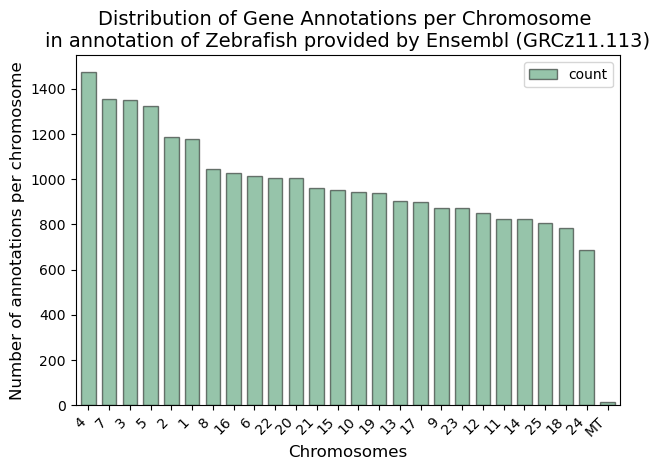

IndexError: index 0 is out of bounds for axis 0 with size 0

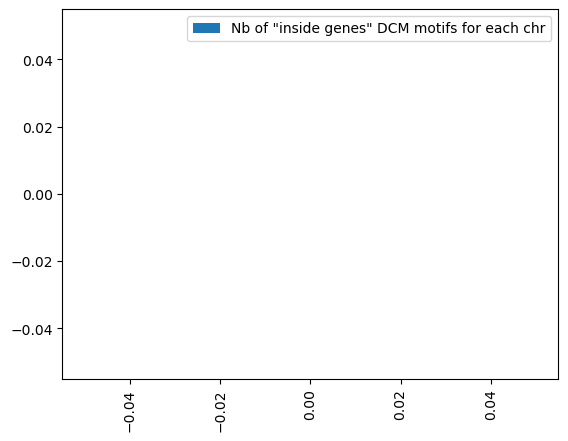

In [55]:
# Plot distribution
plt.figure(figsize=(20, 10))

# Distribution of genes annotated in Ensembl annotation
tmp_=pd.DataFrame(features_genes_ranges.df["Chromosome"].value_counts())
tmp_.plot(kind='bar', color='seagreen', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of annotations per chromosome', fontsize=12)
plt.title(f'Distribution of Gene Annotations per Chromosome \nin annotation of {annotation_name}', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# Distribution of DCM motifs in Ensembl annotation, not normalized
tmp_merged.plot.bar(x='Chromosome',y='Nb of "inside genes" DCM motifs for each chr', color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of motifs (falling \ninside genes) per chromosome', fontsize=12)
plt.title(f'Distribution of DCM Motifs detected per Chromosome in \nannotation of {annotation_name}', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Distribution of DCM motifs in Ensembl annotation, normalized
tmp_merged.plot.bar(x='Chromosome',y='count_normalized', color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.xlabel('Chromosomes', fontsize=12)
plt.ylabel('Number of motifs per chromosome \ndivided by chromosome length', fontsize=12)
plt.title(f'Distribution of DCM Motifs detected per Chromosome, normalized by \neach chromosome length, in annotation of {annotation_name}', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Motifs distribution in genes**

In [56]:
# Distribution of the nb of motifs per gene
df = inclusion_annotation
df['custom_gene_id'] = df['Chromosome'].astype(str) + ':' + df['Start_b'].astype(str) + '-' + df['End_b'].astype(str) + ':' + df['Strand_b'].astype(str)
gene_motifs_count = df.groupby('custom_gene_id')['second_idx'].nunique().reset_index(name='motif_count')
gene_motifs_count=genes_lengths_file.merge(gene_motifs_count)
gene_motifs_count['normalized_count']=gene_motifs_count['motif_count']/gene_motifs_count['Length']

In which chromosomes are located the genes having high number of motifs compared to the rest of the chromosomes?

In [57]:
upper_quantile=gene_motifs_count.normalized_count.quantile(0.75)
chr_=gene_motifs_count.loc[gene_motifs_count['normalized_count']>upper_quantile,'Chromosome']
chr_.value_counts()

Chromosome
4     436
3     385
7     345
5     292
1     288
22    287
2     270
6     262
8     253
15    247
20    246
9     235
16    225
25    219
21    216
17    213
18    211
23    211
19    202
10    198
13    198
11    193
12    173
14    168
24    141
MT      2
Name: count, dtype: int64

Distribution of the number of motifs per gene, NOT normalized by the genes lengths

In [64]:
gene_motifs_count['gene_id'].nunique()

24465

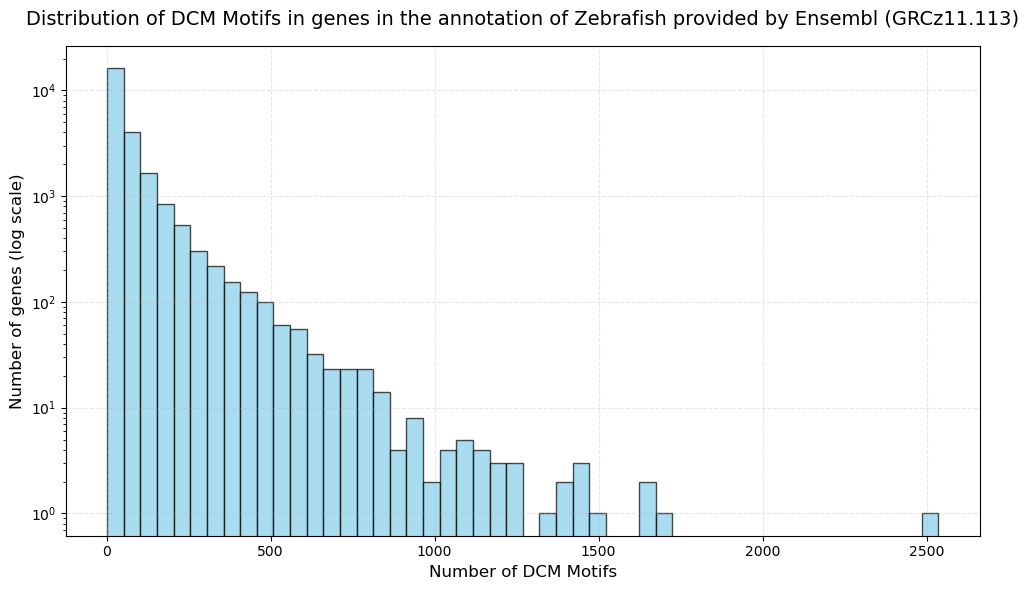

In [58]:
x = gene_motifs_count['motif_count']

plt.figure(figsize=(10, 6))  # Set a larger figure size
plt.hist(x, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add descriptive labels and title
plt.xlabel('Number of DCM Motifs', fontsize=12)
plt.ylabel('Number of genes (log scale)', fontsize=12)
plt.title(f'Distribution of DCM Motifs in genes in the annotation of {annotation_name}', fontsize=14, pad=15)

# Customize x-axis ticks
#plt.xticks(np.arange(min(x), max(x)+1, 1.0), rotation=45)
plt.yscale('log')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [ ]:
x = gene_motifs_count['normalized_count']

plt.figure(figsize=(10, 6))  # Set a larger figure size
plt.hist(x, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add descriptive labels and title
plt.xlabel('Number of DCM Motifs normalized by the genes lengths', fontsize=12)
plt.ylabel('Number of genes (log scale)', fontsize=12)
plt.title(f'Distribution of DCM Motifs in genes, normalized by genes lengths, \nin the annotation of {annotation_name}', fontsize=14, pad=15)

# Customize x-axis ticks
#plt.xticks(np.arange(min(x), max(x)+1, 1.0), rotation=45)
plt.yscale('log')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()

In [ ]:
distribution = gene_motifs_count['motif_count'].value_counts().sort_index()
distribution_df = pd.DataFrame([distribution]).T.reset_index() 
distribution_df = distribution_df.rename(columns={'motif_count' : 'nb_of_motifs_per_gene', 'count' : 'nb_of_genes'})
distribution_df

bins = np.linspace(0,max(distribution_df['nb_of_motifs_per_gene']),30)
bins = np.round(bins, 0)
bins = bins.astype(int)
labels = [f"{bins[i]}-{bins[i+1]+1}" for i in range(len(bins)-1)]
distribution_df['bin'] = pd.cut(distribution_df['nb_of_motifs_per_gene'], bins=bins, labels=labels, right=True)
binned_distribution = distribution_df.groupby('bin')['nb_of_genes'].sum()

plt.figure(figsize=(30, 10))
binned_distribution.plot.bar(color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.title(f'Distribution of DCM Motifs per Gene (binned). Y-axis is log scaled. \nAnnotation: {annotation_name}', fontsize=35)
plt.ylabel('Log Number of Genes', fontsize=35)
plt.xlabel('Number of DCM Motifs per Gene (binned)', fontsize=35)
plt.yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Distribution of the number of motifs per gene normalized by the genes lengths

In [ ]:
distribution_normalized = gene_motifs_count['normalized_count'].value_counts().sort_index()
distribution_normalized_df = pd.DataFrame([distribution_normalized]).T.reset_index() 
distribution_normalized_df = distribution_normalized_df.rename(columns={'normalized_count' : 'normalized_nb_of_motifs_per_gene', 'count' : 'nb_of_genes'})

bins = np.linspace(0,max(distribution_normalized_df['normalized_nb_of_motifs_per_gene']),30)
#bins = np.round(bins, 0)
labels = [f"{round(bins[i],3)}-{round(bins[i+1]+1,3)}" for i in range(len(bins)-1)]
distribution_normalized_df['bin'] = pd.cut(distribution_normalized_df['normalized_nb_of_motifs_per_gene'], bins=bins, labels=labels, right=True)
binned_distribution = distribution_normalized_df.groupby('bin')['nb_of_genes'].sum()

plt.figure(figsize=(30, 10))
binned_distribution.plot.bar(color='steelblue', edgecolor='black', width=0.7, alpha=0.5)
plt.title(f'Distribution of DCM Motifs per Gene normalized by the genes lengths. Y-axis is scaled. \nAnnotation: {annotation_name}', fontsize=35)
plt.ylabel('Log Number of Genes', fontsize=35)
plt.xlabel('Number of DCM Motifs per Gene normalized by genes lengths (binned)', fontsize=35)
plt.yscale('log')
plt.xticks(rotation=45, ha='right', fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **Select some genes for GO**

Gene Ontology Analysis: run in a separate scripts in '/pasteur/zeus/projets/p02/Fast_npz/Naomie/GO/enrichGO.ipynb'

In [29]:
high_dcm_counts=gene_motifs_count.loc[np.where(gene_motifs_count['motif_count'] >= np.quantile(gene_motifs_count['motif_count'], .95))]
genes_high_dcm_counts = list(high_dcm_counts['gene_id'])

with open('genes_high_dcm_counts.pkl', 'wb') as f:
    pickle.dump(genes_high_dcm_counts, f)

len(genes_high_dcm_counts)

3545

In [30]:
low_dcm_counts=gene_motifs_count.loc[np.where(gene_motifs_count['motif_count'] <= np.quantile(gene_motifs_count['motif_count'], .05))]
genes_low_dcm_counts = list(low_dcm_counts['gene_id'])

with open('genes_low_dcm_counts.pkl', 'wb') as f:
    pickle.dump(genes_low_dcm_counts, f)

len(genes_low_dcm_counts)

5401

**Z-score filtering**

**Re-annotation of filtered motifs**

**Distribution of the nb of motifs per gene after filtering out outliers genes**

*Not normalized*

*Normalized*

**Distribution of genes in chr after filtering outliers genes** Has the distribution of genes in chromosomes changed after filtering?

### **Compute Proportions**

In [31]:
print(f"We detect DCM motifs in {df['custom_gene_id'].nunique()} unique genes.") 

if species == 'Zebrafish':
    print("Knowing there are 25'592 coding genes and 6'599 non-coding genes in Ensembl GRCz11.113.")
elif species == 'Mouse':
    print("Knowing there are 22'011 coding genes, 39'067 non-coding genes, 13'770 pseudogenes in Ensembl GRCm39.")

We detect DCM motifs in 70760 unique genes.
Knowing there are 22'011 coding genes, 39'067 non-coding genes, 13'770 pseudogenes in Ensembl GRCm39.


In [32]:
print(f"The mean of the number of motifs per gene is {round(distribution_df['nb_of_motifs_per_gene'].mean(),2)}")
print(f"with a std of {round(distribution_df['nb_of_motifs_per_gene'].std(),2)}")

The mean of the number of motifs per gene is 867.16
with a std of 802.86


**Percentage of motifs detected in at least one gene**

In [33]:
percent_inside_gene = round(get_percentage(len(motifs_genes),len(motifs)))
percent_intergenic = round(get_percentage(len(motifs)-len(motifs_genes),len(motifs)))
print("Percentage of motifs found in at least one gene: {0}%, Percentage of motifs not found in any gene: {1}%".format(percent_inside_gene,percent_intergenic))

Percentage of motifs found in at least one gene: 34%, Percentage of motifs not found in any gene: 66%


In [34]:
nb_duplicated_motifs = len(inclusion_annotation[(inclusion_annotation['second_idx'].duplicated())==True])
nb_unique_motifs = len(inclusion_annotation[(inclusion_annotation['second_idx'].duplicated())==False])

## Distinct genes correspond to the same motif:
percent_duplicated_occurrences = round(get_percentage(nb_duplicated_motifs,len(inclusion_annotation)),2)
percent_unique_occurrences = round(get_percentage(nb_unique_motifs,len(inclusion_annotation)),2)

## A motif might correspond to distinct genes:
duplicated_values = inclusion_annotation["second_idx"][inclusion_annotation["second_idx"].duplicated()]
duplicates_in_motifs_genes = motifs_genes["second_idx"].isin(duplicated_values)
count_duplicates = duplicates_in_motifs_genes.sum()
percent_duplicated_motifs = round(get_percentage(count_duplicates,len(motifs_genes)),2)

print(f"Out of all the matches between a DCM motif and a position in the genome ({len(inclusion_annotation)}), {nb_unique_motifs} correspond to a unique motif while {nb_duplicated_motifs} correspond to motifs matching several positions")
print(f"In other words, {percent_duplicated_occurrences} % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching several positions")
print(f"In other words, {percent_unique_occurrences} % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching a unique position")
print(f"In the other way around, {percent_duplicated_motifs} % of our motifs are found in several genes in the genome")

Out of all the matches between a DCM motif and a position in the genome (5475926), 5277024 correspond to a unique motif while 198902 correspond to motifs matching several positions
In other words, 3.63 % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching several positions
In other words, 96.37 % of positions in the genome for which a match with a DCM motif was found, correspond to motifs matching a unique position
In the other way around, 3.23 % of our motifs are found in several genes in the genome


**Gene Motifs found in at least one transcript vs. in no transcript i.e. in intronic part found between two non-overlapping transcripts of a gene**

In [35]:
nb_motifs_inside_transcripts = len(motifs_genes[motifs_genes["inside_transcript"]==True])

percent_inside_transcript = round(get_percentage(nb_motifs_inside_transcripts,len(motifs_genes)),3)
percent_outside_transcript = round(get_percentage(len(motifs_genes)-nb_motifs_inside_transcripts,len(motifs_genes)),3)

print("Percentage of motifs present in genes that are found in at least one transcript: {0}% \nPercentage of motifs present in genes that are not found in any transcript (=intronic part between two non-overlapping transcripts): {1} %".format(percent_inside_transcript,percent_outside_transcript))

Percentage of motifs present in genes that are found in at least one transcript: 99.883% 
Percentage of motifs present in genes that are not found in any transcript (=intronic part between two non-overlapping transcripts): 0.117 %


In [36]:
print("More precisely, {0} motifs that are present in at least one gene were not found in any transcript, knowing there are {1} motifs found in at least one gene".format(len(motifs_genes[motifs_genes["inside_transcript"]==False]),len(motifs_genes)))
print("These motifs correspond to motifs falling inside intronic regions found between two non-overlapping transcripts inside a gene")

More precisely, 6168 motifs that are present in at least one gene were not found in any transcript, knowing there are 5277024 motifs found in at least one gene
These motifs correspond to motifs falling inside intronic regions found between two non-overlapping transcripts inside a gene


**--> this should be neglected**

#### **Motifs only inside coding transcripts**

In [37]:
motifs_transcripts = motifs_genes[motifs_genes["inside_transcript"]==True]
nb_motifs_transcripts = len(motifs_transcripts)

coding_transcripts = motifs_transcripts[motifs_transcripts["transcript_type"]=="coding"]
nb_coding = len(coding_transcripts)
percent_coding = round(get_percentage(nb_coding,nb_motifs_transcripts),2)

print(f'Percentage of motifs genes found in "coding transcripts" only: {percent_coding} %')

Percentage of motifs genes found in "coding transcripts" only: 48.92 %


**Motifs in exons, considering motifs only found inside coding transcripts**

In [38]:
exonic_coding = coding_transcripts[coding_transcripts["inside_exon"]==True]
percent_exonic_coding = round(get_percentage(len(exonic_coding) , nb_coding),2)
print(f'Percentage of motifs found in "coding transcripts" that are exonic: {percent_exonic_coding}%')

Percentage of motifs found in "coding transcripts" that are exonic: 11.3%


*Proportions of exonic motifs present in coding transcripts only that are in CDS or in 5' UTR or in 3' UTR*

In [39]:
exonic_coding_cds = exonic_coding[exonic_coding["inside_CDS"]==True]
percent_exonic_coding_cds = round(get_percentage(len(exonic_coding_cds),len(exonic_coding)))

exonic_coding_five_prime_utr = exonic_coding[exonic_coding["inside_five_prime_utr"]==True]
percent_exonic_coding_five_prime_utr = round(get_percentage(len(exonic_coding_five_prime_utr),len(exonic_coding)))

exonic_coding_three_prime_utr = exonic_coding[exonic_coding["inside_three_prime_utr"]==True]
percent_exonic_coding_three_prime_utr = round(get_percentage(len(exonic_coding_three_prime_utr),len(exonic_coding)))

print(f"Percentage of motifs found in exonic part of coding transcripts that are \nin CDS: {percent_exonic_coding_cds}% \nin 5' UTR: {percent_exonic_coding_five_prime_utr}% \nin 3' UTR: {percent_exonic_coding_three_prime_utr}%")

Percentage of motifs found in exonic part of coding transcripts that are 
in CDS: 47% 
in 5' UTR: 10% 
in 3' UTR: 39%


**Motifs in introns, considering motifs only found inside coding transcripts**

In [40]:
intronic_coding_transcript = coding_transcripts[coding_transcripts["inside_exon"]==False]
percent_intronic_coding = round(get_percentage(len(intronic_coding_transcript),len(coding_transcripts)),2)

print(f"Percentage of motifs found in coding transcripts that are found inside intronic regions: \n{percent_intronic_coding}%")

Percentage of motifs found in coding transcripts that are found inside intronic regions: 
88.7%


#### **Motifs only inside non-coding transcripts**

In [41]:
non_coding_transcripts = motifs_transcripts[motifs_transcripts["transcript_type"]=="non-coding"]
nb_non_coding = len(non_coding_transcripts)
percent_non_coding = round(get_percentage(nb_non_coding,nb_motifs_transcripts),2)

print(f"Percentage of motifs genes found in non-coding transcripts only: {percent_non_coding}")

Percentage of motifs genes found in non-coding transcripts only: 33.89


**Motifs in exons, considering motifs only found inside non-coding transcripts**

In [42]:
exonic_non_coding = non_coding_transcripts[non_coding_transcripts["inside_exon"]==True]
percent_exonic_non_coding = round(get_percentage(len(exonic_non_coding) , nb_non_coding),2)
print(f"Percentage of motifs found in non-coding transcripts that are exonic: {percent_exonic_non_coding}%") 

Percentage of motifs found in non-coding transcripts that are exonic: 13.27%


*Proportions of exonic motifs present in non-coding transcripts only that are in CDS or in 5' UTR or in 3' UTR*

In [43]:
exonic_non_coding_cds = exonic_non_coding[exonic_non_coding["inside_CDS"]==True]
percent_exonic_non_coding_cds = round(get_percentage(len(exonic_non_coding_cds),len(exonic_non_coding)))

exonic_non_coding_five_prime_utr = exonic_non_coding[exonic_non_coding["inside_five_prime_utr"]==True]
percent_exonic_non_coding_five_prime_utr = round(get_percentage(len(exonic_non_coding_five_prime_utr),len(exonic_non_coding)))

exonic_non_coding_three_prime_utr = exonic_non_coding[exonic_non_coding["inside_three_prime_utr"]==True]
percent_exonic_non_coding_three_prime_utr = round(get_percentage(len(exonic_non_coding_three_prime_utr),len(exonic_non_coding)))

print(f"Percentage of motifs found in exonic part of non-coding transcripts that are in CDS: {percent_exonic_non_coding_cds}% \nin 5' UTR: {percent_exonic_non_coding_five_prime_utr}% \nin 3' UTR: {percent_exonic_non_coding_three_prime_utr}%")

Percentage of motifs found in exonic part of non-coding transcripts that are in CDS: 0% 
in 5' UTR: 0% 
in 3' UTR: 0%


**--> these should equal zero**

**Motifs in introns, considering motifs only found inside non-coding transcripts**

In [44]:
intronic_non_coding_transcript = non_coding_transcripts[non_coding_transcripts["inside_exon"]==False]
percent_intronic_non_coding = round(get_percentage(len(intronic_non_coding_transcript),len(non_coding_transcripts)),2)

print(f"Percentage of motifs found in non-coding transcripts that are found inside intronic part: {percent_intronic_non_coding}%")

Percentage of motifs found in non-coding transcripts that are found inside intronic part: 86.73%


#### **Motifs inside at least two transcripts: a coding (ORF) and a non-coding (no ORF)**

In [45]:
coding_non_coding = motifs_transcripts[motifs_transcripts["transcript_type"]=="both"]
nb_coding_non_coding = len(coding_non_coding)
percent_coding_non_coding = round(get_percentage(nb_coding_non_coding,nb_motifs_transcripts),2)

print(f"Percentage of motifs genes found both in coding and non-coding transcripts (ambiguity): {percent_coding_non_coding}")

Percentage of motifs genes found both in coding and non-coding transcripts (ambiguity): 17.19


**Motifs in exons, considering motifs found both inside coding and non-coding transcripts**

In [46]:
exonic_coding_non_coding = coding_non_coding[coding_non_coding["inside_exon"]==True]
percent_exonic_coding_non_coding = round(get_percentage(len(exonic_coding_non_coding) , nb_coding_non_coding),2)

print(f"Percentage of motifs found both in coding and non-coding transcripts that are exonic: {percent_exonic_coding_non_coding}") 

Percentage of motifs found both in coding and non-coding transcripts that are exonic: 16.36


*Proportions of exonic motifs present both in coding and non-coding transcripts that are in CDS or in 5' UTR or in 3' UTR*

In [47]:
exonic_coding_non_coding_cds = exonic_coding_non_coding[exonic_coding_non_coding["inside_CDS"]==True]
percent_exonic_coding_non_coding_cds = round(get_percentage(len(exonic_coding_non_coding_cds),len(exonic_coding_non_coding)))

exonic_coding_non_coding_five_prime_utr = exonic_coding_non_coding[exonic_coding_non_coding["inside_five_prime_utr"]==True]
percent_exonic_coding_non_coding_five_prime_utr = round(get_percentage(len(exonic_coding_non_coding_five_prime_utr),len(exonic_coding_non_coding)))

exonic_coding_non_coding_three_prime_utr = exonic_coding_non_coding[exonic_coding_non_coding["inside_three_prime_utr"]==True]
percent_exonic_coding_non_coding_three_prime_utr = round(get_percentage(len(exonic_coding_non_coding_three_prime_utr),len(exonic_coding_non_coding)))

print(f"Percentage of motifs found in exonic part of both coding and non-coding transcripts that are in CDS: {percent_exonic_coding_non_coding_cds}% \nin 5' UTR: {percent_exonic_coding_non_coding_five_prime_utr}% \nin 3' UTR: {percent_exonic_coding_non_coding_three_prime_utr}%")

Percentage of motifs found in exonic part of both coding and non-coding transcripts that are in CDS: 33% 
in 5' UTR: 6% 
in 3' UTR: 14%


**Motifs in introns, considering motifs found both inside coding and non-coding transcripts**

In [48]:
intronic_coding_non_coding = coding_non_coding[coding_non_coding["inside_exon"]==False]
percent_intronic_coding_non_coding = round(get_percentage(len(intronic_coding_non_coding),len(coding_non_coding)),2)

print(f"Percentage of motifs found in both coding and non-coding transcripts that are found inside intronic part: {percent_intronic_coding_non_coding}%")

Percentage of motifs found in both coding and non-coding transcripts that are found inside intronic part: 83.64%


### **Plot proportions**

Text(0.5, 1.0, 'Proportion of DCM motifs that are included in at least one gene. Gene \nboundaries are defined in the annotation of Mouse provided by Ensembl (GRCm39) \nas the outermost boundaries of all its transcripts')

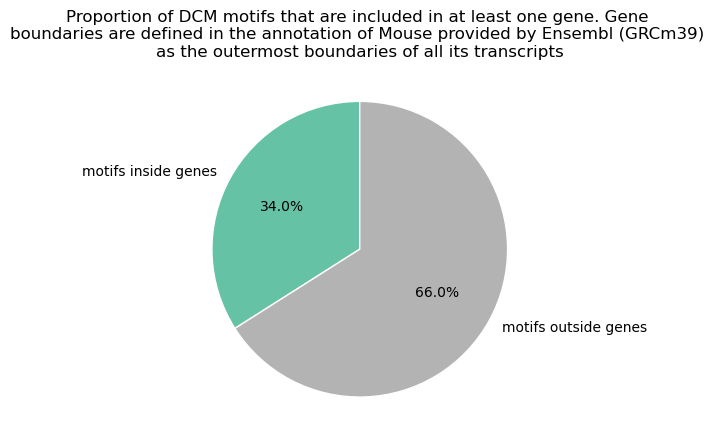

In [49]:
fig, ax = plt.subplots()
percentage=[percent_inside_gene,percent_intergenic]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["motifs inside genes","motifs outside genes"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportion of DCM motifs that are included in at least one gene. Gene \nboundaries are defined in the annotation of {annotation_name} \nas the outermost boundaries of all its transcripts')


Text(0.5, 1.0, 'Proportions of genes, matching a DCM motif, that were \nmapped by a motif mapping only one gene vs. several genes \n Mouse provided by Ensembl (GRCm39)')

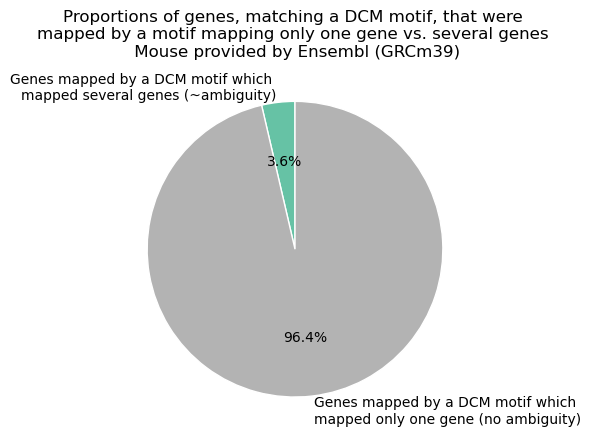

In [50]:
## Distinct genes correspond to the same motif:
fig, ax = plt.subplots()
percentage=[percent_duplicated_occurrences, percent_unique_occurrences]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Genes mapped by a DCM motif which \nmapped several genes (~ambiguity)","Genes mapped by a DCM motif which \nmapped only one gene (no ambiguity)"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportions of genes, matching a DCM motif, that were \nmapped by a motif mapping only one gene vs. several genes \n {annotation_name}')

Text(0.5, 1.0, 'Proportions of DCM motifs mapping one or several genes in the genome. \nConsidering the annotation of Mouse provided by Ensembl (GRCm39)')

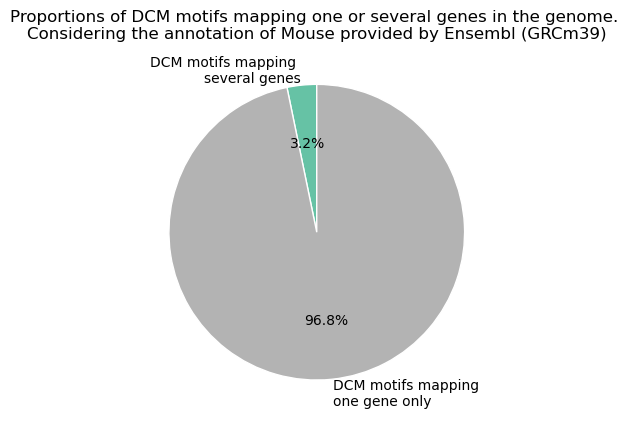

In [60]:
# Motifs matching more than one gene

fig, ax = plt.subplots()
percentage=[percent_duplicated_motifs,(100-percent_duplicated_motifs)]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["DCM motifs mapping \nseveral genes","DCM motifs mapping \none gene only"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportions of DCM motifs mapping one or several genes in the genome. \nConsidering the annotation of {annotation_name}')


Text(0.5, 1.0, 'Proportion of DCM motifs, present in at least one gene, that are \nfound in at least a transcript or in no transcript. \nGene boundaries are defined in the annotation \nof the Mouse provided by Ensembl (GRCm39) \nas the outermost boundaries of all its transcripts')

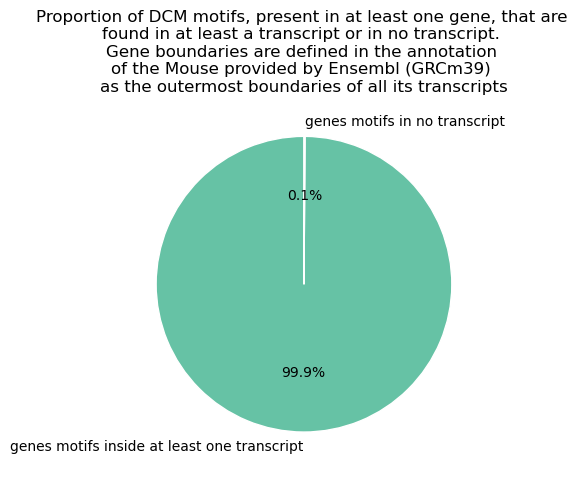

In [52]:
fig, ax = plt.subplots()
percentage=[percent_inside_transcript, percent_outside_transcript]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["genes motifs inside at least one transcript","genes motifs in no transcript"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportion of DCM motifs, present in at least one gene, that are \nfound in at least a transcript or in no transcript. \nGene boundaries are defined in the annotation \nof the {annotation_name} \nas the outermost boundaries of all its transcripts')


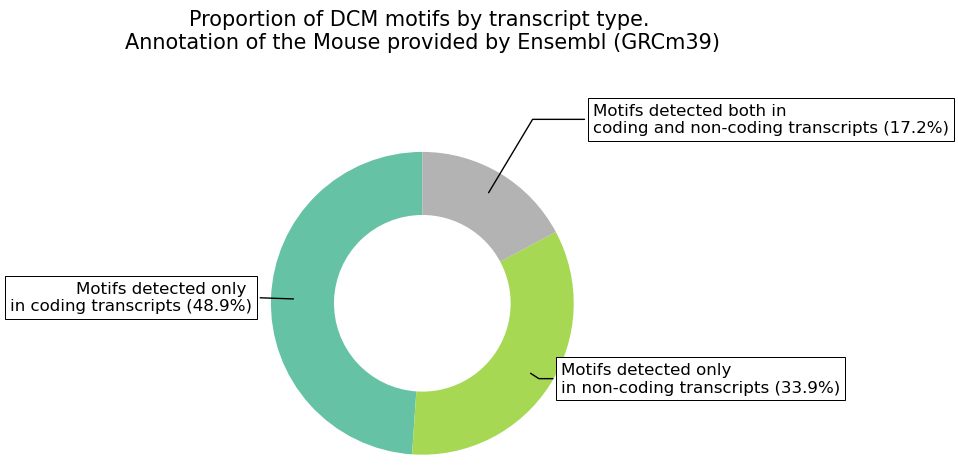

In [53]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(aspect="equal"))
percentage = [percent_coding, percent_non_coding, percent_coding_non_coding]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))

labels = ["Motifs detected only \nin coding transcripts", 
          "Motifs detected only \nin non-coding transcripts",
          "Motifs detected both in \ncoding and non-coding transcripts"]

wedges, texts = ax.pie(percentage, 
                       wedgeprops=dict(width=0.5), 
                       startangle=90, 
                       colors=colors,
                      radius=1.2)

bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=10, va="center")

# Manually adjust xytext for problematic labels
xytext_adjustments = [
    (1.35, 1.4),    # first label
    (1.1, 1.1),    # second label (adjusted to prevent overlap)
    (1.35, 1.7)     # third label
]

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(f"{labels[i]} ({percentage[i]:.1f}%)", 
                xy=(x, y), 
                xytext=(xytext_adjustments[i][0]*np.sign(x), xytext_adjustments[i][1]*y),
                horizontalalignment=horizontalalignment, 
                fontsize=12,
                **kw)


ax.set_title(f'Proportion of DCM motifs by transcript type. \nAnnotation of the {annotation_name}', 
             fontsize=15,  # Adjust title font size
             pad=70)

plt.tight_layout()

Text(0.5, 1.0, 'Proportion of exonic or intronic motifs detected in coding transcripts. \nA motif is considered exonic if it is detected in at least one exon. \nConsidering the annotation of Mouse provided by Ensembl (GRCm39)')

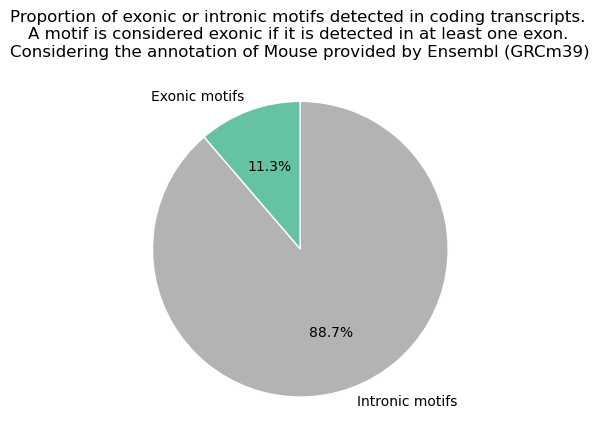

In [54]:
fig, ax = plt.subplots()
percentage=[percent_exonic_coding,percent_intronic_coding]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic motifs","Intronic motifs"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportion of exonic or intronic motifs detected in coding transcripts. \nA motif is considered exonic if it is detected in at least one exon. \nConsidering the annotation of {annotation_name}')

Text(0.5, 1.0, 'Proportion of exonic or intronic motifs detected in non-coding transcripts. \nA motif is considered exonic if it is detected in at least one exon. \nConsidering the annotation of Mouse provided by Ensembl (GRCm39)')

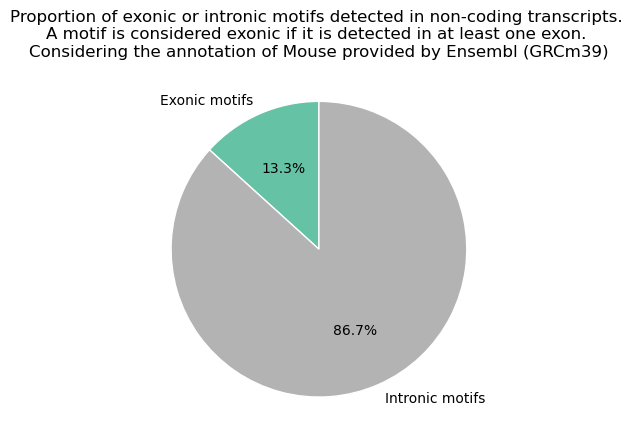

In [55]:
fig, ax = plt.subplots()
percentage=[percent_exonic_non_coding,percent_intronic_non_coding]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic motifs","Intronic motifs"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportion of exonic or intronic motifs detected in non-coding transcripts. \nA motif is considered exonic if it is detected in at least one exon. \nConsidering the annotation of {annotation_name}')

Text(0.5, 1.0, 'Proportion of exonic or intronic motifs detected in at least one coding and one \nnon-coding transcript. A motif is considered exonic if it is detected in at least \none exon. Considering the annotation of the Mouse provided by Ensembl (GRCm39)')

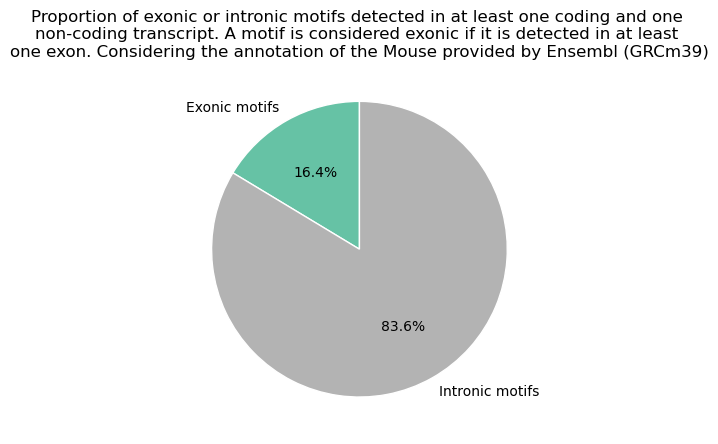

In [56]:
fig, ax = plt.subplots()
percentage=[percent_exonic_coding_non_coding,percent_intronic_coding_non_coding]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["Exonic motifs", "Intronic motifs"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f'Proportion of exonic or intronic motifs detected in at least one coding and one \nnon-coding transcript. A motif is considered exonic if it is detected in at least \none exon. Considering the annotation of the {annotation_name}')

Text(0.5, 1.0, "Proportion of exonic DCM motifs detected only in coding transcripts \nthat are found in CDS, in 5' UTR or in 3' UTR. \nConsidering the annotation of the Mouse provided by Ensembl (GRCm39)")

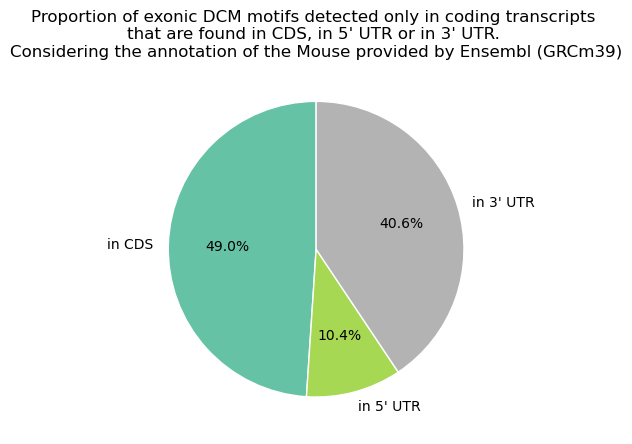

In [57]:
fig, ax = plt.subplots()
percentage=[percent_exonic_coding_cds,percent_exonic_coding_five_prime_utr,percent_exonic_coding_three_prime_utr]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["in CDS", "in 5' UTR", "in 3' UTR"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of exonic DCM motifs detected only in coding transcripts \nthat are found in CDS, in 5' UTR or in 3' UTR. \nConsidering the annotation of the {annotation_name}")

In [58]:
percentage=[percent_exonic_non_coding_cds,percent_exonic_non_coding_five_prime_utr,percent_exonic_non_coding_three_prime_utr]
percentage

[0, 0, 0]

Text(0.5, 1.0, "Proportion of exonic DCM motifs detected, detected in at least one \ncoding and one non-coding transcript, that are found \nin CDS, in 5' UTR or in 3' UTR. \nConsidering the Mouse provided by Ensembl (GRCm39)")

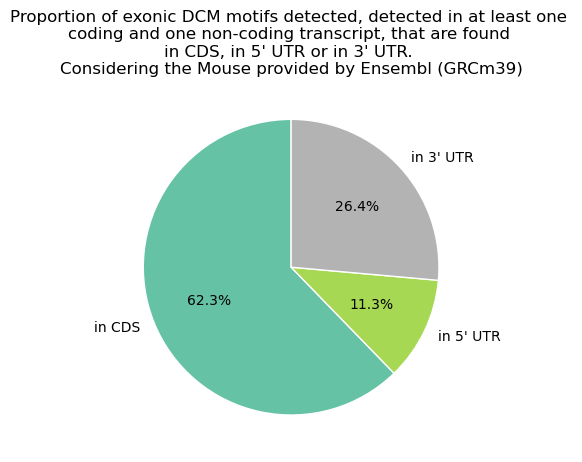

In [59]:
fig, ax = plt.subplots()
percentage=[percent_exonic_coding_non_coding_cds,percent_exonic_coding_non_coding_five_prime_utr,percent_exonic_coding_non_coding_three_prime_utr]
colors = plt.cm.Set2(np.linspace(0, 1, len(percentage)))
ax.pie(percentage, labels=["in CDS", "in 5' UTR", "in 3' UTR"], autopct='%1.1f%%', colors=colors, startangle=90,wedgeprops={'edgecolor': 'white'})
ax.set_title(f"Proportion of exonic DCM motifs detected, detected in at least one \ncoding and one non-coding transcript, that are found \nin CDS, in 5' UTR or in 3' UTR. \nConsidering the {annotation_name}")